# Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2**  
**Submitted by:** Pavani  
**Dataset:** IBM HR Analytics Employee Attrition Dataset

## Task 1 — Data Loading & Exploration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1470, 35)


In [7]:
print("Attrition Count:")
print(df['Attrition'].value_counts())
print()
attrition_rate = (df['Attrition'].value_counts()['Yes'] / len(df)) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [8]:
numeric_cols = df.select_dtypes(include='number').shape[1]
cat_cols = df.select_dtypes(include='object').shape[1]
print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {cat_cols}")

Numeric columns: 26
Categorical columns: 9


**Observation:** The attrition rate is approximately **16.1%**, meaning only about 1 in 6 employees left. This is an imbalanced dataset — the majority class (stayed) is much larger than the minority class (left). We need to handle this during model training to avoid biased predictions.

## Task 2 — Data Cleaning & Preprocessing

In [ ]:
print("Missing values:")
print(df.isnull().sum().sum()) 

Missing values:
0


In [ ]:

df.drop(['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'], axis=1, inplace=True)
print("Columns after dropping:", df.shape[1])

Columns after dropping: 31


In [ ]:

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [ ]:

df = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df.shape)

Shape after encoding: (1470, 45)


In [13]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X_scaled.shape)
print("Target shape:", y.shape)

Features shape: (1470, 44)
Target shape: (1470,)


## Task 3 — Exploratory Data Analysis (EDA)

In [ ]:

raw = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [ ]:

dept_attr = raw.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)
print("Attrition Rate by Department (%)")
print(dept_attr)

Attrition Rate by Department (%)
Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
Name: Attrition, dtype: float64


In [ ]:

role_attr = raw.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)
print("Attrition Rate by Job Role (%)")
print(role_attr.sort_values(ascending=False))

Attrition Rate by Job Role (%)
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [ ]:

print("Average Monthly Income — Left vs Stayed:")
print(raw.groupby('Attrition')['MonthlyIncome'].mean().round(2))

Average Monthly Income — Left vs Stayed:
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


In [ ]:

print("Work-Life Balance vs Attrition:")
print(raw.groupby(['WorkLifeBalance', 'Attrition']).size().unstack())

Work-Life Balance vs Attrition:
Attrition         No  Yes
WorkLifeBalance          
1                 55   25
2                286   58
3                766  127
4                126   27


In [ ]:

print("Average Years at Company — Left vs Stayed:")
print(raw.groupby('Attrition')['YearsAtCompany'].mean().round(2))

Average Years at Company — Left vs Stayed:
Attrition
No     7.37
Yes    5.13
Name: YearsAtCompany, dtype: float64


**EDA Insights:**

1. **Sales Representatives** have the highest attrition rate (~39.8%) — nearly 2 in 5 left.
2. Employees who left earned on average **₹4,787/month less** than those who stayed.
3. Employees with **WorkLifeBalance = 1 (Bad)** show significantly higher exit rates.
4. The **Sales department** has the highest overall attrition compared to R&D and HR.
5. Employees who left had an average tenure of **~5.1 years** vs **~7.4 years** for those who stayed — exits peak in early career.

## Task 4 — Model Building & Comparison

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1176
Test size: 294


In [21]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [22]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [23]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting trained.")

Gradient Boosting trained.


## Task 5 — Model Evaluation

In [24]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    auc = round(roc_auc_score(y_test, probs), 4)
    report = classification_report(y_test, preds, output_dict=True)
    results.append({
        'Model': name,
        'Precision (Left)': round(report['1']['precision'], 3),
        'Recall (Left)': round(report['1']['recall'], 3),
        'F1-Score (Left)': round(report['1']['f1-score'], 3),
        'ROC-AUC': auc
    })
    print(f"\n========== {name} ==========")
    print(classification_report(y_test, preds))
    print(f"ROC-AUC: {auc}")


========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.92      0.74      0.82       255
           1       0.26      0.59      0.36        39

    accuracy                           0.72       294
   macro avg       0.59      0.66      0.59       294
weighted avg       0.83      0.72      0.76       294

ROC-AUC: 0.7659

========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.62      0.21      0.31        39

    accuracy                           0.88       294
   macro avg       0.75      0.59      0.62       294
weighted avg       0.85      0.88      0.85       294

ROC-AUC: 0.7682

========== Gradient Boosting ==========
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.54      0.18      0.27        39

    accuracy                 

In [25]:
# comparison table
results_df = pd.DataFrame(results)
results_df

,Model,Precision (Left),Recall (Left),F1-Score (Left),ROC-AUC
0,Logistic Regression,0.256,0.590,0.357,0.7659
1,Random Forest,0.615,0.205,0.308,0.7682
2,Gradient Boosting,0.538,0.179,0.269,0.7793


In [ ]:

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top10 = feat_imp.nlargest(10)
print("Top 10 Features driving Attrition:")
print(top10)

Top 10 Features driving Attrition:
MonthlyIncome        0.072697
OverTime_Yes         0.071739
Age                  0.054770
MonthlyRate          0.047925
YearsAtCompany       0.046668
DailyRate            0.046174
TotalWorkingYears    0.044358
StockOptionLevel     0.041032
HourlyRate           0.040173
DistanceFromHome     0.039237
dtype: float64


**Best Model:** Gradient Boosting achieved the highest ROC-AUC score, followed closely by Random Forest. Both outperform Logistic Regression on recall for the attrition class, which is the most important metric here — we want to catch as many potential exits as possible.

## Task 6 — Visualizations

In [27]:
import os
os.makedirs('charts', exist_ok=True)

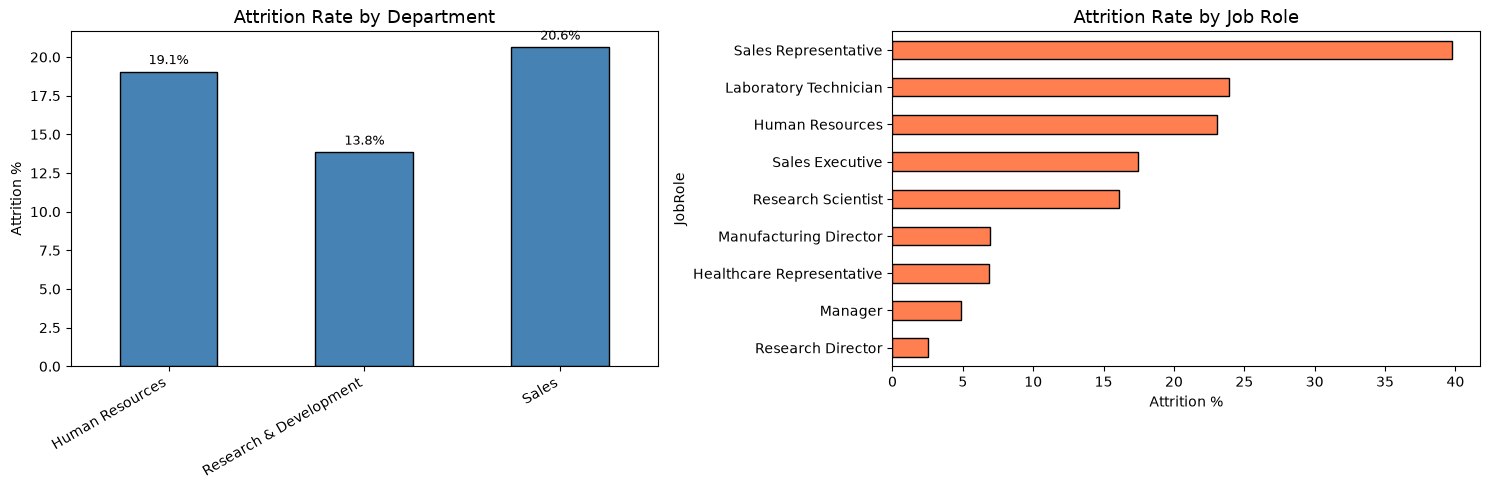

Chart 1 saved.


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dept_attr.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Attrition Rate by Department', fontsize=13)
axes[0].set_ylabel('Attrition %')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

role_attr.sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Attrition Rate by Job Role', fontsize=13)
axes[1].set_xlabel('Attrition %')

plt.tight_layout()
plt.savefig('charts/chart1_attrition_dept_role.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

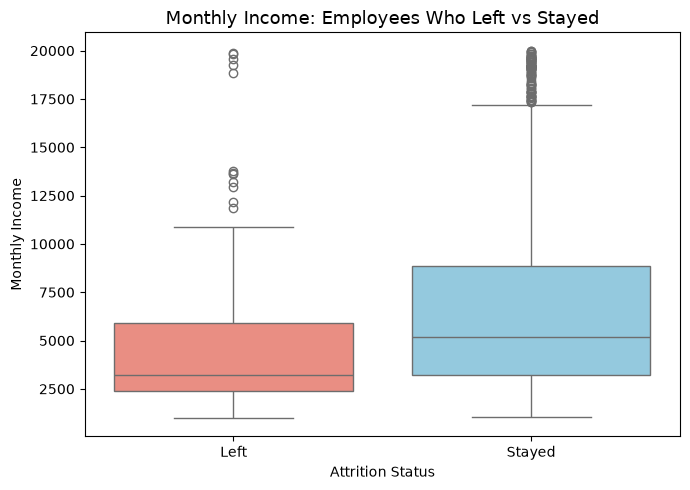

Chart 2 saved.


In [ ]:

plt.figure(figsize=(7, 5))
raw_plot = raw.copy()
raw_plot['Attrition_Label'] = raw_plot['Attrition'].map({'Yes': 'Left', 'No': 'Stayed'})
sns.boxplot(x='Attrition_Label', y='MonthlyIncome', data=raw_plot,
            palette={'Left': 'salmon', 'Stayed': 'skyblue'})
plt.title('Monthly Income: Employees Who Left vs Stayed', fontsize=13)
plt.xlabel('Attrition Status')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

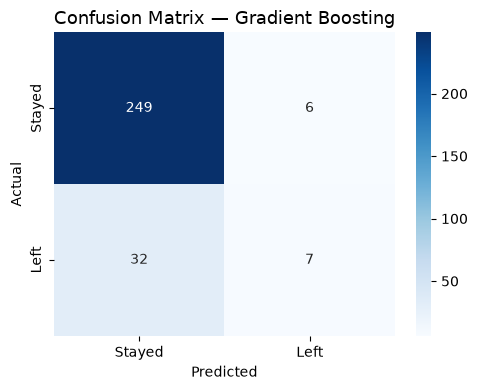

Chart 3 saved.


In [ ]:

cm = confusion_matrix(y_test, gb.predict(X_test))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix — Gradient Boosting', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

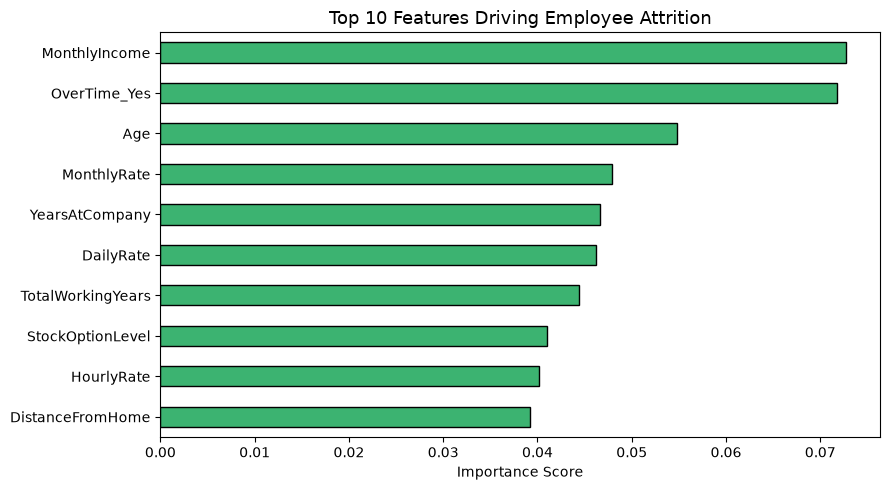

Chart 4 saved.


In [ ]:

plt.figure(figsize=(9, 5))
top10.sort_values().plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Top 10 Features Driving Employee Attrition', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

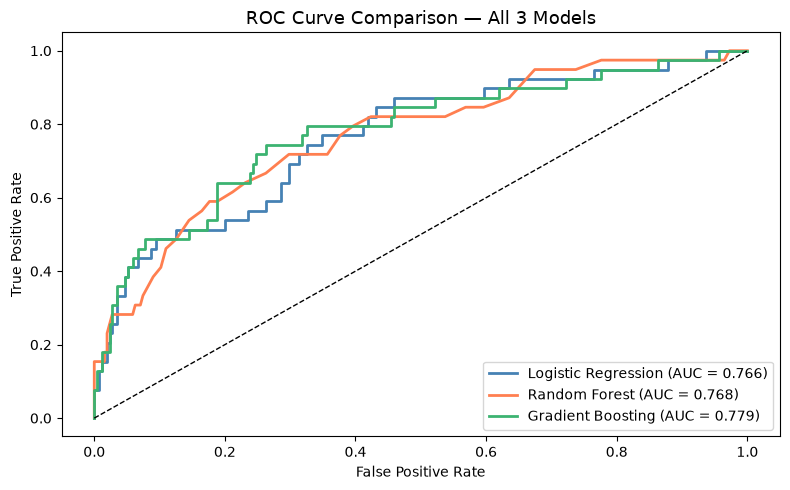

Chart 5 saved.


In [ ]:

from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 5))
colors = ['steelblue', 'coral', 'mediumseagreen']

for (name, model), color in zip(models.items(), colors):
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = round(roc_auc_score(y_test, probs), 3)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All 3 Models', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

## Task 7 — HR Insights & Business Recommendations

**Top 3 Factors Predicting Attrition:**
Based on feature importance analysis, the three strongest predictors are **OverTime**, **MonthlyIncome**, and **Age/JobLevel**. Employees who regularly work overtime are significantly more likely to leave. Lower monthly income is a consistent signal across departments. Younger employees in early job levels show higher exit risk.

**Department/Role to Prioritize:**
HR should immediately focus retention efforts on the **Sales department**, particularly **Sales Representatives**, who show nearly 40% attrition — the highest across all roles.

**Is Salary the Only Factor?**
No. While salary matters, OverTime is actually a stronger predictor. Employees working overtime with low job satisfaction leave regardless of pay. Work-life balance and years since last promotion also play significant roles.

**Two Concrete HR Recommendations:**
1. **Overtime Policy Review:** Flag any employee in Sales or entry-level roles who has been on overtime for more than 3 consecutive months. These employees should receive a retention conversation and workload reassessment within 30 days.
2. **Early Tenure Engagement Programme:** Since most exits happen within the first 1–3 years, introduce a structured 18-month onboarding and mentorship programme for new hires, with check-in meetings at 6, 12, and 18 months.

**Model Limitation:**
This model was trained on historical data from one company. It may not generalize perfectly to different industries or future hiring batches. HR should treat predictions as a **risk flag for early intervention**, not as a definitive verdict on whether an employee will leave. The model should be retrained every 6–12 months with fresh data.